In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("../data/final/final_data.xlsx")

In [3]:
df.head(5)

,order_ID,order_date,first_class,order_day_name,on_truck_scan_date,on_truck_scan_day_name,order_to_truck_scan_days,ready_to_ship_date,pickup_date,processing_time,real_watting_time_ready_to_ship_until_leaving_facilities,estimate_delivery_date,estimate_shipping_time,estimate_total_order_time,real_arrival_date
0,CA-2019-121755,2019-01-16,0,Wednesday,2019-01-23,Wednesday,7.0,NaT,NaT,NaN,NaN,2019-01-21,NaN,5,NaT
1,CA-2019-121755,2019-01-16,0,Wednesday,2019-01-23,Wednesday,7.0,NaT,NaT,NaN,NaN,2019-01-21,NaN,5,NaT
2,CA-2019-118255,2019-03-11,1,Monday,2019-03-13,Wednesday,2.0,NaT,NaT,NaN,NaN,2019-03-13,NaN,2,NaT
3,CA-2019-118255,2019-03-11,1,Monday,2019-03-13,Wednesday,2.0,NaT,NaT,NaN,NaN,2019-03-13,NaN,2,NaT
4,CA-2019-169194,2019-06-20,0,Thursday,2019-06-26,Wednesday,6.0,NaT,NaT,NaN,NaN,2019-06-24,NaN,4,NaT


In [4]:
df.columns

Index(['order_ID', 'order_date', 'first_class', 'order_day_name',
       'on_truck_scan_date', 'on_truck_scan_day_name',
       'order_to_truck_scan_days', 'ready_to_ship_date', 'pickup_date',
       'processing_time',
       'real_watting_time_ready_to_ship_until_leaving_facilities',
       'estimate_delivery_date', 'estimate_shipping_time',
       'estimate_total_order_time', 'real_arrival_date'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23171 entries, 0 to 23170
Data columns (total 15 columns):
 #   Column                                                    Non-Null Count  Dtype         
---  ------                                                    --------------  -----         
 0   order_ID                                                  23171 non-null  str           
 1   order_date                                                23171 non-null  datetime64[us]
 2   first_class                                               23171 non-null  int64         
 3   order_day_name                                            23171 non-null  str           
 4   on_truck_scan_date                                        19076 non-null  datetime64[us]
 5   on_truck_scan_day_name                                    19076 non-null  str           
 6   order_to_truck_scan_days                                  19076 non-null  float64       
 7   ready_to_ship_date                                 

In [6]:
df.isna().sum().sort_values(ascending=False)

real_arrival_date                                           20960
ready_to_ship_date                                          20400
pickup_date                                                 20400
processing_time                                             20400
real_watting_time_ready_to_ship_until_leaving_facilities    20400
estimate_shipping_time                                      20400
on_truck_scan_date                                           4095
on_truck_scan_day_name                                       4095
order_to_truck_scan_days                                     4095
order_ID                                                        0
order_date                                                      0
first_class                                                     0
order_day_name                                                  0
estimate_delivery_date                                          0
estimate_total_order_time                                       0
dtype: int

In [7]:
df["order_ID"].duplicated().sum()

np.int64(18162)

In [8]:
df['order_ID'].value_counts()

order_ID
CA-2020-102925    320
CA-2020-100111    196
CA-2020-164168    180
CA-2019-106950    180
CA-2020-157987    144
                 ... 
CA-2019-146913      1
US-2017-114377      1
CA-2020-107209      1
US-2020-152842      1
CA-2019-122581      1
Name: count, Length: 5009, dtype: int64

In [9]:
df[df['order_ID'] == 'CA-2020-102925'].duplicated().sum()

np.int64(319)

In [10]:
df.loc[23160:23170]

,order_ID,order_date,first_class,order_day_name,on_truck_scan_date,on_truck_scan_day_name,order_to_truck_scan_days,ready_to_ship_date,pickup_date,processing_time,real_watting_time_ready_to_ship_until_leaving_facilities,estimate_delivery_date,estimate_shipping_time,estimate_total_order_time,real_arrival_date
23160,US-2019-115441,2019-07-25,0,Thursday,2019-07-31,Wednesday,6.0,NaT,NaT,NaN,NaN,2019-07-29,NaN,4,NaT
23161,US-2019-115441,2019-07-25,0,Thursday,2019-07-31,Wednesday,6.0,NaT,NaT,NaN,NaN,2019-07-29,NaN,4,NaT
23162,US-2018-129007,2018-09-13,1,Thursday,NaT,NaN,NaN,NaT,NaT,NaN,NaN,2018-09-15,NaN,2,NaT
23163,CA-2018-132388,2018-10-10,1,Wednesday,NaT,NaN,NaN,NaT,NaT,NaN,NaN,2018-10-12,NaN,2,NaT
23164,CA-2019-149272,2019-03-15,0,Friday,2019-03-20,Wednesday,5.0,NaT,NaT,NaN,NaN,2019-03-18,NaN,3,NaT
23165,CA-2019-149272,2019-03-15,0,Friday,2019-03-20,Wednesday,5.0,NaT,NaT,NaN,NaN,2019-03-18,NaN,3,NaT
23166,CA-2020-121559,2020-06-01,0,Monday,2020-06-05,Friday,4.0,NaT,NaT,NaN,NaN,2020-06-05,NaN,4,NaT
23167,CA-2020-121559,2020-06-01,0,Monday,2020-06-05,Friday,4.0,NaT,NaT,NaN,NaN,2020-06-05,NaN,4,NaT
23168,CA-2020-121559,2020-06-01,0,Monday,2020-06-05,Friday,4.0,NaT,NaT,NaN,NaN,2020-06-05,NaN,4,NaT
23169,CA-2020-121559,2020-06-01,0,Monday,2020-06-05,Friday,4.0,NaT,NaT,NaN,NaN,2020-06-05,NaN,4,NaT


In [11]:
df = df.drop_duplicates()

In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 5010 entries, 0 to 23156
Data columns (total 15 columns):
 #   Column                                                    Non-Null Count  Dtype         
---  ------                                                    --------------  -----         
 0   order_ID                                                  5010 non-null   str           
 1   order_date                                                5010 non-null   datetime64[us]
 2   first_class                                               5010 non-null   int64         
 3   order_day_name                                            5010 non-null   str           
 4   on_truck_scan_date                                        3003 non-null   datetime64[us]
 5   on_truck_scan_day_name                                    3003 non-null   str           
 6   order_to_truck_scan_days                                  3003 non-null   float64       
 7   ready_to_ship_date                                       

In [13]:
df.duplicated()

0        False
2        False
4        False
6        False
13       False
         ...  
23135    False
23136    False
23146    False
23148    False
23156    False
Length: 5010, dtype: bool

In [14]:
df["order_ID"].duplicated().sum()

np.int64(1)

In [15]:
df['order_ID'].value_counts().head()

order_ID
CA-2020-101182    2
CA-2019-121755    1
CA-2019-118255    1
CA-2019-169194    1
CA-2019-111682    1
Name: count, dtype: int64

In [16]:
df[df["order_ID"] == "CA-2020-101182"]

,order_ID,order_date,first_class,order_day_name,on_truck_scan_date,on_truck_scan_day_name,order_to_truck_scan_days,ready_to_ship_date,pickup_date,processing_time,real_watting_time_ready_to_ship_until_leaving_facilities,estimate_delivery_date,estimate_shipping_time,estimate_total_order_time,real_arrival_date
5964,CA-2020-101182,2020-09-04,1,Friday,2020-09-07,Monday,3.0,NaT,NaT,NaN,NaN,2020-09-06,NaN,2,NaT
5965,CA-2020-101182,2020-09-04,1,Friday,2020-09-08,Tuesday,4.0,NaT,NaT,NaN,NaN,2020-09-06,NaN,2,NaT


In [17]:
df['order_ID'].is_unique

False

In [18]:
df["real_whole_process"] = df["real_arrival_date"] - df['order_date']

In [19]:
df = df.rename(columns={
    'real_watting_time_ready_to_ship_until_leaving_facilities': 'waiting_time_ready_to_pickup'
})

In [20]:
df_time_line = df[
    [
        # 🆔 ID
        'order_ID',

        # 📅 Order info
        'order_date',
        'order_day_name',

        # 🚚 Warehouse / processing
        'on_truck_scan_date',
        'on_truck_scan_day_name',
        'ready_to_ship_date',
        'pickup_date',

        # 📦 Final delivery
        'real_arrival_date',

        # ⏱ Stage durations
        'order_to_truck_scan_days',
        'processing_time',
        'waiting_time_ready_to_pickup',

        # 📊 Estimates
        'estimate_delivery_date',
        'estimate_shipping_time',
        'estimate_total_order_time',

        # ⚙️ Flags
        'first_class'
    ]
]

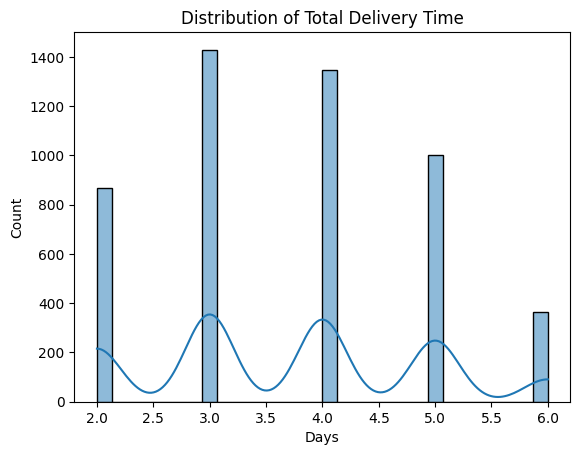

In [21]:
sns.histplot(df['estimate_total_order_time'], bins=30, kde=True)
plt.title('Distribution of Total Delivery Time')
plt.xlabel('Days')
plt.ylabel('Count')
plt.show()


In [25]:
df_ = df["real_whole_process"]

In [28]:
df_.dropna(inplace = True)

In [31]:
df_.info()

<class 'pandas.Series'>
Index: 333 entries, 38 to 23135
Series name: real_whole_process
Non-Null Count  Dtype          
--------------  -----          
333 non-null    timedelta64[us]
dtypes: timedelta64[us](1)
memory usage: 5.2 KB


In [1]:
sns.histplot(df_df["real_whole_process"], bins=20, kde=True)
plt.title('Distribution of Total Delivery Time')
plt.xlabel('Days')
plt.ylabel('Count')
plt.show()


NameError: name 'sns' is not defined

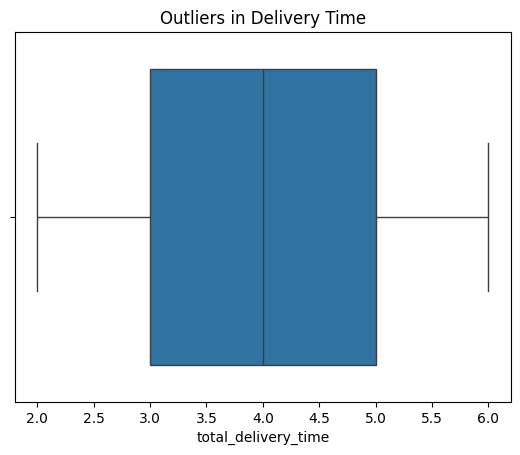

In [10]:
sns.boxplot(x=df['total_delivery_time'])
plt.title('Outliers in Delivery Time')
plt.show()

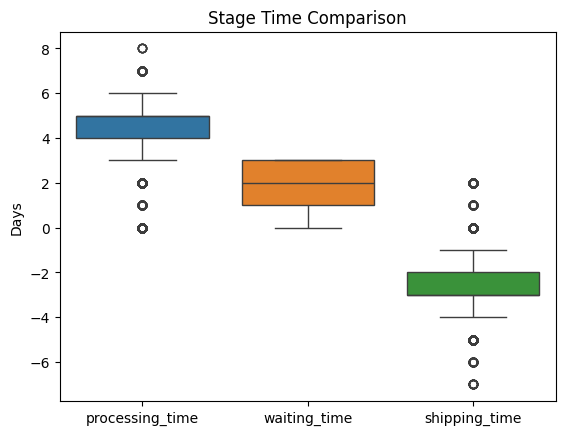

In [11]:
sns.boxplot(data=df[['processing_time','waiting_time','shipping_time']])
plt.title('Stage Time Comparison')
plt.ylabel('Days')
plt.show()

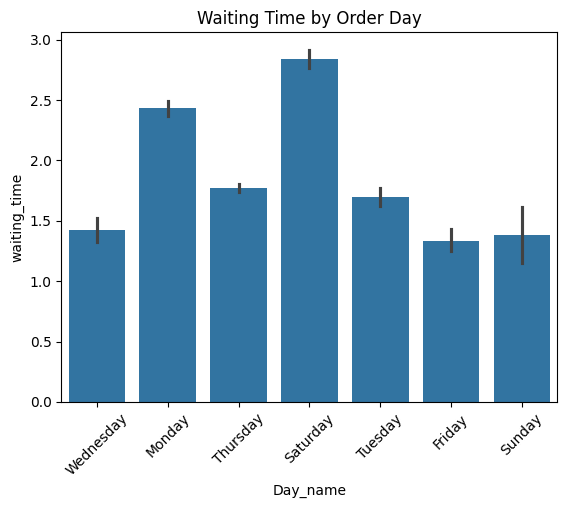

In [12]:
sns.barplot(x='Day_name', y='waiting_time', data=df)
plt.title('Waiting Time by Order Day')
plt.xticks(rotation=45)
plt.show()

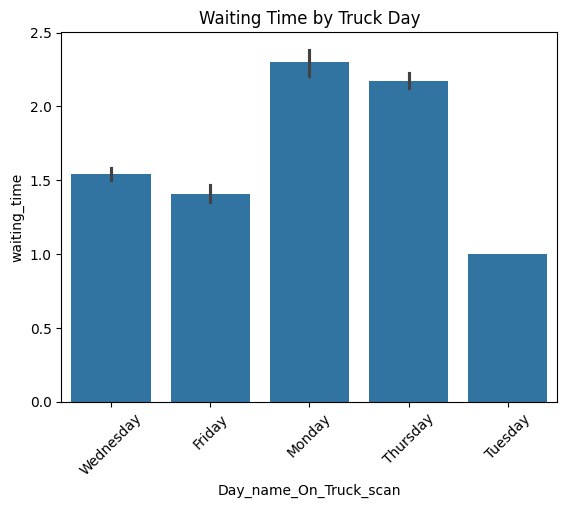

In [13]:
sns.barplot(x='Day_name_On_Truck_scan', y='waiting_time', data=df)
plt.title('Waiting Time by Truck Day')
plt.xticks(rotation=45)
plt.show()

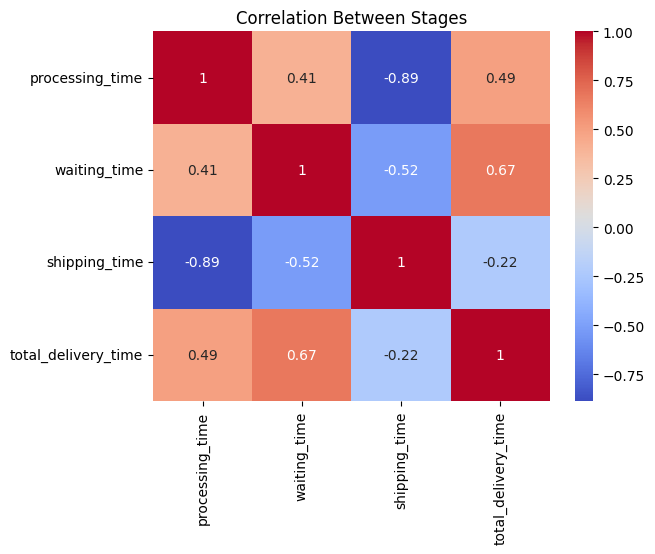

In [14]:
sns.heatmap(df[['processing_time','waiting_time','shipping_time','total_delivery_time']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Between Stages')
plt.show()

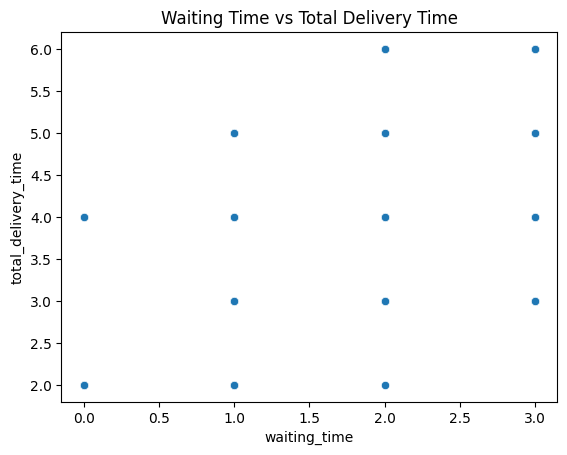

In [15]:
sns.scatterplot(x='waiting_time', y='total_delivery_time', data=df)
plt.title('Waiting Time vs Total Delivery Time')
plt.show()

In [19]:
df.rename(columns={
    'Diff_OrderDate_OnTruckScanDate': 'fulfillment_time'
}, inplace=True)

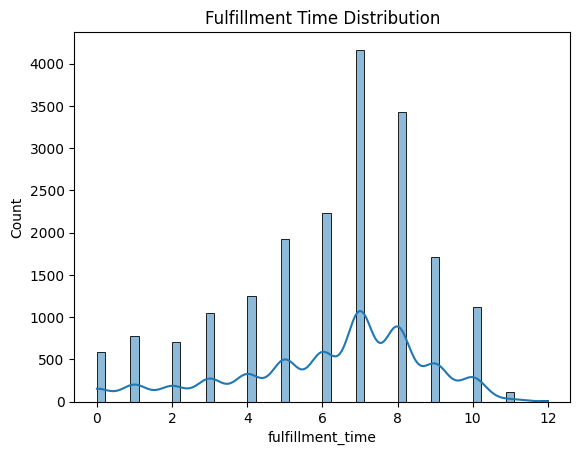

In [20]:
sns.histplot(df['fulfillment_time'], kde=True)
plt.title('Fulfillment Time Distribution')
plt.show()

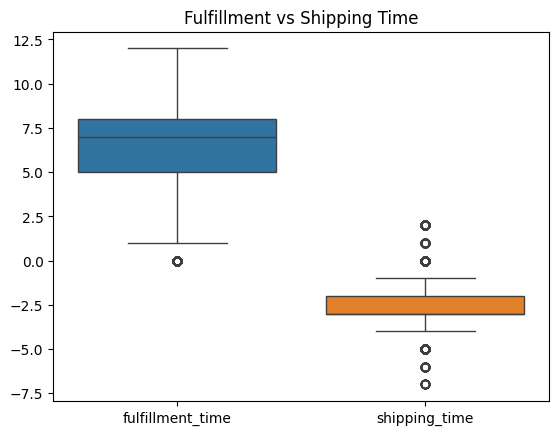

In [21]:
sns.boxplot(data=df[['fulfillment_time','shipping_time']])
plt.title('Fulfillment vs Shipping Time')
plt.show()

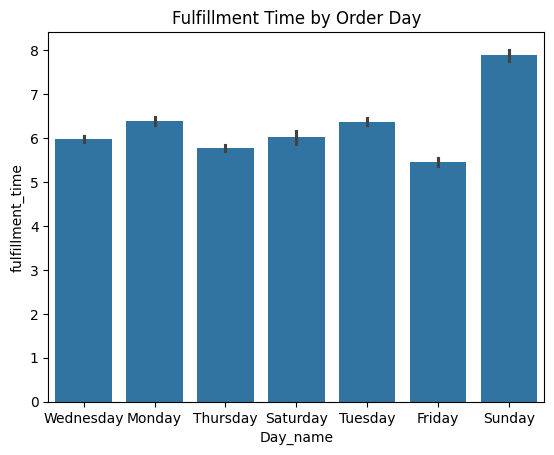

In [22]:
sns.barplot(x='Day_name', y='fulfillment_time', data=df)
plt.title('Fulfillment Time by Order Day')
plt.show()

In [23]:
df['estimated_waiting'] = df['fulfillment_time'] - df['fulfillment_time'].median()

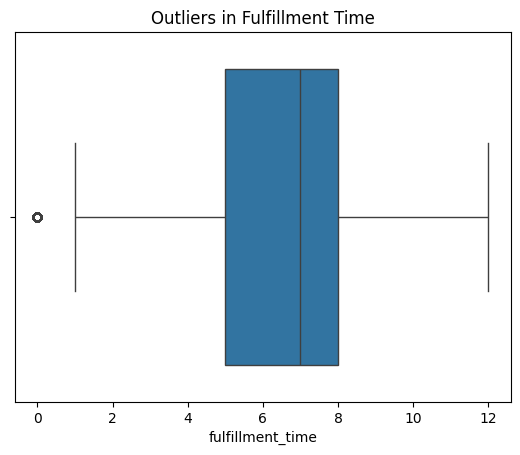

In [24]:
sns.boxplot(x=df['fulfillment_time'])
plt.title('Outliers in Fulfillment Time')
plt.show()

“The time between order creation and truck loading includes both processing and waiting due to fixed truck schedules. Since these components are not separately tracked, we analyze them as a combined fulfillment time. Variations in this metric are largely driven by order timing relative to truck departure days.”

In [17]:
df["total_delivery_time"].describe()

count    23171.000000
mean         3.668810
std          1.143718
min          2.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          6.000000
Name: total_delivery_time, dtype: float64

In [6]:
df['total_delivery_time'].mean()

np.float64(3.6688101506193087)

In [7]:
(df['total_delivery_time'] <= 3).mean()

np.float64(0.46187044150015105)

In [8]:
df['total_delivery_time'].quantile([0.5, 0.75, 0.9, 0.95])

0.50    4.0
0.75    5.0
0.90    5.0
0.95    5.0
Name: total_delivery_time, dtype: float64

In [9]:
df['processing_time'].mean()

np.float64(4.3247924936845905)

In [10]:
df['waiting_time'].mean()

np.float64(1.8451822446770119)

In [11]:
df['shipping_time'].mean()

np.float64(-2.486827859978347)

In [1]:
df[['processing_time','waiting_time','shipping_time']].mean()

NameError: name 'df' is not defined